# Métricas Personalizadas (feval) — LightGBM
## Optimización enfocada en fraude de hospedaje (MCC 7011)

**Objetivo**: Implementar 6 funciones `feval` que reemplazan la métrica estándar de LightGBM, cada una con un enfoque distinto para minimizar la tasa de falsos positivos en establecimientos de hospedaje.

**Métrica central del proyecto**: `FP_ratio = FP / (TP + FP)`

| # | Nombre | Dirección |
|---|---|---|
| 1 | `hotel_fp_ratio` | Minimizar |
| 2 | `hotel_recall_minus_fpratio` | Maximizar |
| 3 | `hotel_fbeta_precision` | Maximizar |
| 4 | `hotel_cost_matrix` | Maximizar |
| 5 | `hotel_precision_at_min_recall` | Maximizar |
| 6 | `composite_hotel_global` | Maximizar |

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# ── Hiperparámetros de las métricas ──────────────────────────────────────────
ALPHA_M2  = 0.5    # M2: peso del FP ratio en recall - α·FP_ratio
BETA_M3   = 0.5    # M3: β para F_beta (β<1 → prioriza precisión)
W_TP      = 1      # M4: peso TP en cost matrix
W_FP      = 3      # M4: peso FP en cost matrix (FP cuesta 3x más)
W_FN      = 1      # M4: peso FN en cost matrix
THETA_M5  = 0.70   # M5: recall mínimo exigido (SLA)
LAM_M6    = 0.7    # M6: peso hotel vs global (70% hotel, 30% global)
ALPHA_M6  = 0.5    # M6: α componente hotel
BETA_M6   = 0.3    # M6: β componente global

RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"LightGBM version: {lgb.__version__}")
print(f"Procesados: {DATA_PROC}")


LightGBM version: 4.6.0
Procesados: /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI/data/processed


## 2. Carga de datos y split interno

In [2]:
train_df = pd.read_csv(DATA_PROC / "train_features.csv")
test_df  = pd.read_csv(DATA_PROC / "test_features_june.csv")

bool_cols = ['is_fraud', 'is_international', 'is_hotel',
             'hotel_international', 'hotel_high_distance']
for col in bool_cols:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].astype(bool)

# Split interno temporal: meses 1-4 → entrenamiento, mes 5 → validación
train_inner = train_df[train_df["transaction_month"] < 5].copy()
val_df      = train_df[train_df["transaction_month"] == 5].copy()

print(f"Train interno : {len(train_inner):,} filas  (meses 1-4)")
print(f"Validación    : {len(val_df):,} filas  (mes 5)")
print(f"Test junio    : {len(test_df):,} filas  (mes 6)")
print()
print(f"Hotel en val  : {val_df['is_hotel'].sum():,} txns  "
      f"| fraudes hotel val : {val_df[val_df['is_hotel']]['is_fraud'].sum()}")
print(f"Hotel en test : {test_df['is_hotel'].sum():,} txns  "
      f"| fraudes hotel test: {test_df[test_df['is_hotel']]['is_fraud'].sum()}")


Train interno : 66,644 filas  (meses 1-4)
Validación    : 17,173 filas  (mes 5)
Test junio    : 16,186 filas  (mes 6)

Hotel en val  : 1,511 txns  | fraudes hotel val : 73
Hotel en test : 1,457 txns  | fraudes hotel test: 73


## 3. Preparación de features (igual que baseline)

In [3]:
TARGET = "is_fraud"

manual_drop = {
    TARGET,
    "transaction_id", "pan_masked", "pan_hash", "DE2_PAN",
    "DE35_track2_data_masked", "DE37_retrieval_reference_number",
    "DE38_authorization_code", "DE41_terminal_id", "DE42_card_acceptor_id",
    "DE43_card_acceptor_name_location", "DE102_account_id_1", "DE103_account_id_2",
    "client_home_city", "bank_code", "bank_name", "bank_country", "bank_tier",
    "approved", "DE39_response_code", "response_description",
    "DE44_additional_response_data", "transaction_date", "transaction_datetime",
}

def build_matrix(train_part, val_part, test_part):
    all_cols = [c for c in train_part.columns if c not in manual_drop]
    cat_cols = train_part[all_cols].select_dtypes(
        include=["object", "category", "string"]).columns.tolist()
    # Sólo one-hot encode categoricals con cardinalidad baja; descartar el resto
    low_card  = [c for c in cat_cols if train_part[c].nunique() <= 50]
    high_card = [c for c in cat_cols if train_part[c].nunique() >  50]

    feat_cols = [c for c in all_cols if c not in high_card]

    X_tr = pd.get_dummies(train_part[feat_cols], columns=low_card,
                          drop_first=True, dtype=float)
    X_va = pd.get_dummies(val_part[feat_cols],   columns=low_card,
                          drop_first=True, dtype=float)
    X_te = pd.get_dummies(test_part[feat_cols],  columns=low_card,
                          drop_first=True, dtype=float)

    X_va = X_va.reindex(columns=X_tr.columns, fill_value=0)
    X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    y_tr = train_part[TARGET].astype(int)
    y_va = val_part[TARGET].astype(int)
    y_te = test_part[TARGET].astype(int)

    if high_card:
        print(f"  Descartadas por alta cardinalidad: {high_card}")
    return X_tr, y_tr, X_va, y_va, X_te, y_te

X_train, y_train, X_val, y_val, X_test, y_test = build_matrix(
    train_inner, val_df, test_df
)

# Máscaras de hotel (índices alineados con las matrices ya particionadas)
hotel_mask_val  = val_df["is_hotel"].values.astype(bool)
hotel_mask_test = test_df["is_hotel"].values.astype(bool)

y_val_np  = y_val.values
y_test_np = y_test.values

print(f"Features finales : {X_train.shape[1]}")
print(f"Hotel val mask   : {hotel_mask_val.sum()} txns  "
      f"| fraude: {y_val_np[hotel_mask_val].sum()}")
print(f"Hotel test mask  : {hotel_mask_test.sum()} txns  "
      f"| fraude: {y_test_np[hotel_mask_test].sum()}")


  Descartadas por alta cardinalidad: ['client_id']
Features finales : 108
Hotel val mask   : 1511 txns  | fraude: 73
Hotel test mask  : 1457 txns  | fraude: 73


## 4. LightGBM Datasets y parámetros base

In [4]:
lgb_train_ds = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
lgb_val_ds   = lgb.Dataset(X_val,   label=y_val,   reference=lgb_train_ds,
                            free_raw_data=False)

BASE_PARAMS = dict(
    objective        = "binary",
    learning_rate    = 0.06,
    num_leaves       = 15,
    max_depth        = -1,
    min_child_samples= 40,
    max_bin          = 63,
    force_col_wise   = True,
    verbose          = -1,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    reg_alpha        = 0.05,
    reg_lambda       = 0.10,
    class_weight     = "balanced",
    random_state     = RANDOM_STATE,
    n_jobs           = 4,
)
NUM_BOOST_ROUND = 500
EARLY_STOPPING  = 50

# Grid de umbrales para búsqueda dinámica dentro de cada feval
THRESHOLDS = np.linspace(0.05, 0.65, 13)

print("Datasets LightGBM listos.")
print(f"Grid de umbrales: {THRESHOLDS.round(2)}")


Datasets LightGBM listos.
Grid de umbrales: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65]


## 5. Definición de las 6 funciones feval

Cada función usa un **closure** para capturar la máscara `is_hotel` y las etiquetas reales del set de validación. Dentro del feval, se realiza búsqueda dinámica del umbral óptimo para que la métrica no colapse con el desbalance de clases (~5% fraude).

```
feval(preds, dataset) → (nombre, valor, is_higher_better)
```

> **Nota**: LightGBM pasa probabilidades en `preds` para `objective="binary"`. Se aplica `np.clip(preds, 0, 1)` como salvaguarda.

In [5]:
def _cm_hotel(y_h, p_h, t):
    """Calcula TP, FP, FN en subconjunto hotel dado un umbral t."""
    y_pred = (p_h >= t).astype(int)
    tp = int(np.sum((y_h == 1) & (y_pred == 1)))
    fp = int(np.sum((y_h == 0) & (y_pred == 1)))
    fn = int(np.sum((y_h == 1) & (y_pred == 0)))
    return tp, fp, fn


# ── Métrica 1: hotel_fp_ratio ──────────────────────────────────────────────
# FP_ratio = FP / (TP + FP) exclusivamente en hospedaje.
# Búsqueda: menor FP_ratio con recall_hotel >= 0.50.
# is_higher_better = False (minimizar).
def make_m1(mask, y_true_full):
    y_h = y_true_full[mask]
    def feval(preds, dataset):
        p = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = 1.0
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
            if rec >= 0.50 and fpr < best:
                best = fpr
        return "hotel_fp_ratio", best, False
    return feval


# ── Métrica 2: hotel_recall_minus_fpratio ─────────────────────────────────
# score = recall_hotel - α * FP_ratio_hotel    (fórmula canónica del proyecto)
# is_higher_better = True (maximizar).
def make_m2(mask, y_true_full, alpha=ALPHA_M2):
    y_h = y_true_full[mask]
    def feval(preds, dataset):
        p = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = -np.inf
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
            s = rec - alpha * fpr
            if s > best:
                best = s
        return "hotel_recall_minus_fpratio", best, True
    return feval


# ── Métrica 3: hotel_fbeta_precision ──────────────────────────────────────
# F_β con β=0.5: precision pesa el doble que recall → penaliza FP directamente.
# is_higher_better = True (maximizar).
def make_m3(mask, y_true_full, beta=BETA_M3):
    y_h   = y_true_full[mask]
    beta2 = beta ** 2
    def feval(preds, dataset):
        p = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = 0.0
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            denom = beta2 * prec + rec
            s = (1 + beta2) * prec * rec / denom if denom > 0 else 0.0
            if s > best:
                best = s
        return "hotel_fbeta_precision", best, True
    return feval


# ── Métrica 4: hotel_cost_matrix ──────────────────────────────────────────
# score = (w_TP·TP - w_FP·FP - w_FN·FN) / N_hotel
# w_FP=3: FP en hotel cuesta 3x más que un FN (fricción al cliente).
# is_higher_better = True (maximizar).
def make_m4(mask, y_true_full, w_tp=W_TP, w_fp=W_FP, w_fn=W_FN):
    y_h = y_true_full[mask]
    n_h = int(mask.sum())
    def feval(preds, dataset):
        p = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = -np.inf
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            s = (w_tp * tp - w_fp * fp - w_fn * fn) / n_h
            if s > best:
                best = s
        return "hotel_cost_matrix", best, True
    return feval


# ── Métrica 5: hotel_precision_at_min_recall ──────────────────────────────
# Maximiza precisión hotel condicionada a recall_hotel >= θ (SLA de detección).
# Si ningún umbral cumple el SLA, retorna 0.
# is_higher_better = True (maximizar).
def make_m5(mask, y_true_full, theta=THETA_M5):
    y_h = y_true_full[mask]
    def feval(preds, dataset):
        p = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = 0.0
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            if rec >= theta and prec > best:
                best = prec
        return "hotel_precision_at_min_recall", best, True
    return feval


# ── Métrica 6: composite_hotel_global ─────────────────────────────────────
# score = λ·score_hotel + (1-λ)·score_global
# Regularizador: evita sobre-optimizar hoteles a costa del rendimiento global.
# is_higher_better = True (maximizar).
def make_m6(mask, y_true_full,
            lam=LAM_M6, alpha=ALPHA_M6, beta=BETA_M6):
    y_h = y_true_full[mask]
    y_g = y_true_full
    def feval(preds, dataset):
        p   = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = -np.inf
        for t in THRESHOLDS:
            # Componente hotel
            tp_h, fp_h, fn_h = _cm_hotel(y_h, p_h, t)
            rec_h = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0.0
            fpr_h = fp_h / (tp_h + fp_h) if (tp_h + fp_h) > 0 else 0.0
            s_h = rec_h - alpha * fpr_h
            # Componente global
            y_pred_g = (p >= t).astype(int)
            tp_g = int(np.sum((y_g == 1) & (y_pred_g == 1)))
            fp_g = int(np.sum((y_g == 0) & (y_pred_g == 1)))
            fn_g = int(np.sum((y_g == 1) & (y_pred_g == 0)))
            rec_g = tp_g / (tp_g + fn_g) if (tp_g + fn_g) > 0 else 0.0
            fpr_g = fp_g / (tp_g + fp_g) if (tp_g + fp_g) > 0 else 0.0
            s_g = rec_g - beta * fpr_g
            s = lam * s_h + (1 - lam) * s_g
            if s > best:
                best = s
        return "composite_hotel_global", best, True
    return feval


# Instanciar las 6 funciones con la máscara de validación
feval_m1 = make_m1(hotel_mask_val, y_val_np)
feval_m2 = make_m2(hotel_mask_val, y_val_np)
feval_m3 = make_m3(hotel_mask_val, y_val_np)
feval_m4 = make_m4(hotel_mask_val, y_val_np)
feval_m5 = make_m5(hotel_mask_val, y_val_np)
feval_m6 = make_m6(hotel_mask_val, y_val_np)

FEVAL_SPECS = [
    ("hotel_fp_ratio",                feval_m1, False),
    ("hotel_recall_minus_fpratio",    feval_m2, True),
    ("hotel_fbeta_precision",         feval_m3, True),
    ("hotel_cost_matrix",             feval_m4, True),
    ("hotel_precision_at_min_recall", feval_m5, True),
    ("composite_hotel_global",        feval_m6, True),
]

print(f"✅ {len(FEVAL_SPECS)} funciones feval definidas.")


✅ 6 funciones feval definidas.


## 6. Entrenamiento de los 6 modelos con early stopping

In [6]:
boosters   = {}
train_logs = {}

for metric_name, feval_fn, higher_better in FEVAL_SPECS:
    print(f"\n{'─'*55}")
    print(f"Entrenando → {metric_name}")

    evals_result = {}
    booster = lgb.train(
        BASE_PARAMS,
        lgb_train_ds,
        num_boost_round       = NUM_BOOST_ROUND,
        valid_sets            = [lgb_val_ds],
        valid_names           = ["val"],
        feval                 = feval_fn,
        callbacks             = [
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=0),
            lgb.record_evaluation(evals_result),
        ],
    )

    best_iter  = booster.best_iteration
    best_score = booster.best_score["val"].get(metric_name, None)
    direction  = "↓ min" if not higher_better else "↑ max"
    print(f"  best_iter  = {best_iter}")
    print(f"  best_score = {best_score:.4f}  ({direction})")

    boosters[metric_name]   = booster
    train_logs[metric_name] = evals_result

print(f"\n✅ Entrenamiento de {len(boosters)} modelos completado.")



───────────────────────────────────────────────────────
Entrenando → hotel_fp_ratio


  best_iter  = 90
  best_score = 0.0244  (↓ min)

───────────────────────────────────────────────────────
Entrenando → hotel_recall_minus_fpratio


  best_iter  = 48
  best_score = 0.5901  (↑ max)

───────────────────────────────────────────────────────
Entrenando → hotel_fbeta_precision


  best_iter  = 84
  best_score = 0.8491  (↑ max)

───────────────────────────────────────────────────────
Entrenando → hotel_cost_matrix


  best_iter  = 84
  best_score = 0.0053  (↑ max)

───────────────────────────────────────────────────────
Entrenando → hotel_precision_at_min_recall


  best_iter  = 114
  best_score = 0.3694  (↑ max)

───────────────────────────────────────────────────────
Entrenando → composite_hotel_global


  best_iter  = 65
  best_score = 0.6319  (↑ max)

✅ Entrenamiento de 6 modelos completado.


## 7. Evaluación en test (junio) — métricas hotel y globales

In [7]:
def evaluate_hotel(booster, metric_name, y_test_full, hotel_mask,
                   min_recall=0.65):
    """
    Evalúa el booster en test junio.
    Selecciona el umbral que minimiza FP_ratio con recall_hotel >= min_recall.
    Reporta métricas de hotel y globales.
    """
    proba = np.clip(booster.predict(X_test), 0, 1)

    p_h = proba[hotel_mask]
    y_h = y_test_full[hotel_mask]

    rows = []
    for t in THRESHOLDS:
        tp, fp, fn = _cm_hotel(y_h, p_h, t)
        tn = int(hotel_mask.sum()) - tp - fp - fn
        rec  = tp / (tp + fn)  if (tp + fn)  > 0 else 0.0
        prec = tp / (tp + fp)  if (tp + fp)  > 0 else 0.0
        fpr  = fp / (tp + fp)  if (tp + fp)  > 0 else 0.0
        rows.append({"t": t, "tp": tp, "fp": fp, "fn": fn,
                     "recall": rec, "precision": prec, "fp_ratio": fpr})

    valid = [r for r in rows if r["recall"] >= min_recall]
    best  = min(valid, key=lambda x: x["fp_ratio"]) if valid else \
            min(rows,  key=lambda x: x["fp_ratio"])

    auc_roc = roc_auc_score(y_test_full, proba)
    pr_auc  = average_precision_score(y_test_full, proba)

    return {
        "metric":          metric_name,
        "best_threshold":  round(best["t"],         3),
        "tp_hotel":        best["tp"],
        "fp_hotel":        best["fp"],
        "fn_hotel":        best["fn"],
        "recall_hotel":    round(best["recall"],     4),
        "precision_hotel": round(best["precision"],  4),
        "fp_ratio_hotel":  round(best["fp_ratio"],   4),
        "auc_roc_global":  round(auc_roc,            4),
        "pr_auc_global":   round(pr_auc,             4),
    }


rows = []
for name, booster in boosters.items():
    row = evaluate_hotel(booster, name, y_test_np, hotel_mask_test)
    rows.append(row)

results_df = pd.DataFrame(rows)

cols_show = ["metric", "best_threshold",
             "tp_hotel", "fp_hotel", "fn_hotel",
             "recall_hotel", "precision_hotel", "fp_ratio_hotel",
             "auc_roc_global", "pr_auc_global"]

results_df[cols_show]


,metric,best_threshold,tp_hotel,fp_hotel,fn_hotel,recall_hotel,precision_hotel,fp_ratio_hotel,auc_roc_global,pr_auc_global
0,hotel_fp_ratio,0.50,50,7,23,0.6849,0.8772,0.1228,0.9031,0.8085
1,hotel_recall_minus_fpratio,0.55,49,7,24,0.6712,0.8750,0.1250,0.9034,0.8056
2,hotel_fbeta_precision,0.50,49,7,24,0.6712,0.8750,0.1250,0.9015,0.8059
3,hotel_cost_matrix,0.50,49,7,24,0.6712,0.8750,0.1250,0.9015,0.8059
4,hotel_precision_at_min_recall,0.45,50,7,23,0.6849,0.8772,0.1228,0.9016,0.8097
5,composite_hotel_global,0.50,49,7,24,0.6712,0.8750,0.1250,0.9026,0.8101


## 8. Visualización: Recall vs FP Ratio por métrica

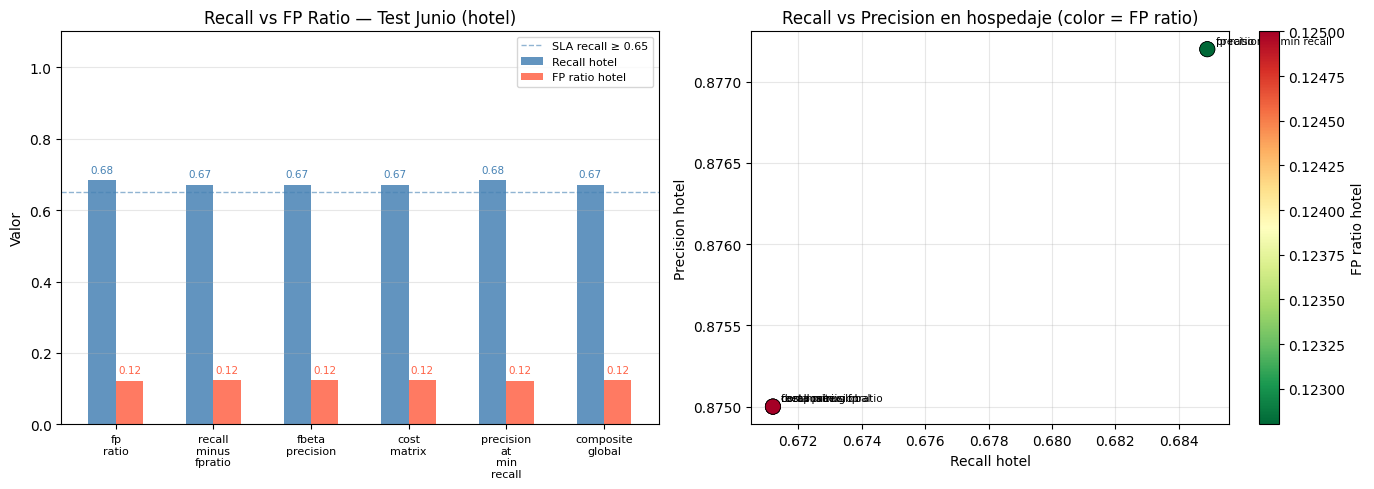

In [8]:
labels  = [r["metric"].replace("hotel_", "").replace("_", "\n") for r in rows]
recalls = [r["recall_hotel"]   for r in rows]
fprs    = [r["fp_ratio_hotel"] for r in rows]
precs   = [r["precision_hotel"] for r in rows]

x = np.arange(len(labels))
w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: Recall vs FP Ratio ──
ax = axes[0]
b1 = ax.bar(x - w/2, recalls, w, label="Recall hotel",   color="steelblue",  alpha=0.85)
b2 = ax.bar(x + w/2, fprs,    w, label="FP ratio hotel", color="tomato",     alpha=0.85)
ax.axhline(0.65, color="steelblue", linestyle="--", linewidth=1, alpha=0.6, label="SLA recall ≥ 0.65")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel("Valor"); ax.set_title("Recall vs FP Ratio — Test Junio (hotel)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                     f"{b.get_height():.2f}", ha="center", fontsize=7.5, color="steelblue")
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                     f"{b.get_height():.2f}", ha="center", fontsize=7.5, color="tomato")

# ── Panel derecho: scatter Recall vs Precision ──
ax2 = axes[1]
sc = ax2.scatter(recalls, precs, c=fprs, cmap="RdYlGn_r", s=120, zorder=3, edgecolors="k", linewidths=0.5)
plt.colorbar(sc, ax=ax2, label="FP ratio hotel")
for i, lbl in enumerate(labels):
    ax2.annotate(lbl.replace("\n", " "), (recalls[i], precs[i]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax2.set_xlabel("Recall hotel"); ax2.set_ylabel("Precision hotel")
ax2.set_title("Recall vs Precision en hospedaje (color = FP ratio)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "custom_metrics_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Resumen comparativo y guardado

In [9]:
summary = results_df[cols_show].copy()
summary["fp_ratio_hotel_pct"]  = (summary["fp_ratio_hotel"]  * 100).round(1)
summary["recall_hotel_pct"]    = (summary["recall_hotel"]    * 100).round(1)
summary["precision_hotel_pct"] = (summary["precision_hotel"] * 100).round(1)

print("=" * 70)
print("RESUMEN — Evaluación en Test Junio (hospedaje MCC 7011)")
print("=" * 70)
for _, r in summary.iterrows():
    print(f"\n  {r['metric']}")
    print(f"    Umbral        : {r['best_threshold']}")
    print(f"    TP hotel      : {r['tp_hotel']}  |  FP hotel: {r['fp_hotel']}  |  FN hotel: {r['fn_hotel']}")
    print(f"    Recall hotel  : {r['recall_hotel_pct']}%")
    print(f"    Precision     : {r['precision_hotel_pct']}%")
    print(f"    FP ratio      : {r['fp_ratio_hotel_pct']}%  ← métrica objetivo")
    print(f"    AUC-ROC global: {r['auc_roc_global']}")

# Guardar
results_df.to_csv(RESULTS_DIR / "custom_metrics_results.csv", index=False)
print(f"\n✅ Guardado en results/custom_metrics_results.csv")

# Mejor modelo por FP ratio (con recall_hotel >= 0.65)
best_row = results_df[results_df["recall_hotel"] >= 0.65].nsmallest(1, "fp_ratio_hotel")
if not best_row.empty:
    print(f"\n🏆 Mejor métrica (FP ratio mín. con recall ≥ 65%):")
    print(f"   → {best_row.iloc[0]['metric']}  "
          f"FP_ratio={best_row.iloc[0]['fp_ratio_hotel']:.4f}  "
          f"recall={best_row.iloc[0]['recall_hotel']:.4f}")


RESUMEN — Evaluación en Test Junio (hospedaje MCC 7011)

  hotel_fp_ratio
    Umbral        : 0.5
    TP hotel      : 50  |  FP hotel: 7  |  FN hotel: 23
    Recall hotel  : 68.5%
    Precision     : 87.7%
    FP ratio      : 12.3%  ← métrica objetivo
    AUC-ROC global: 0.9031

  hotel_recall_minus_fpratio
    Umbral        : 0.55
    TP hotel      : 49  |  FP hotel: 7  |  FN hotel: 24
    Recall hotel  : 67.1%
    Precision     : 87.5%
    FP ratio      : 12.5%  ← métrica objetivo
    AUC-ROC global: 0.9034

  hotel_fbeta_precision
    Umbral        : 0.5
    TP hotel      : 49  |  FP hotel: 7  |  FN hotel: 24
    Recall hotel  : 67.1%
    Precision     : 87.5%
    FP ratio      : 12.5%  ← métrica objetivo
    AUC-ROC global: 0.9015

  hotel_cost_matrix
    Umbral        : 0.5
    TP hotel      : 49  |  FP hotel: 7  |  FN hotel: 24
    Recall hotel  : 67.1%
    Precision     : 87.5%
    FP ratio      : 12.5%  ← métrica objetivo
    AUC-ROC global: 0.9015

  hotel_precision_at_min_rec